<a href="https://colab.research.google.com/github/eelah200/ProblemPrograming/blob/main/apart_set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import matplotlib as mpl

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dasan = pd.read_excel('drive/MyDrive/Colab Notebooks/Mycode/Team_info/dasan.xlsx')
hwado = pd.read_excel('drive/MyDrive/Colab Notebooks/Mycode/Team_info/hwado.xlsx')

In [ ]:
data = pd.concat([dasan, hwado],ignore_index=True)

In [ ]:
#서론: 남양주를 선택한 이유
#1. 수도권에 위치해 있어서 (서울에서 수도권으로 이주하는 추세를 대표하는 도시 중 하나이기 때문에)
#2. 2017~2022년 동안 폭 큰 성장을 이룬 도시 중 하나이기 때문에
#3. 필자의 개인적인 경험이지만, 유년 시절의 남양주시와 현재 시점의 남양주시는 짦은 이래 많은 변화를 보였고,
# 동시에 시골과 도시의 두 가지 면이 보이는 도시라 생각되어 실거래가의 요인이 예상과는 다른 모습을 보일 거라 생각해 선택하게 되었다.

data

,Area,YearMonth,Day,Tran amount,Floor,Construction,Motrgage loan,Fixed rate,Variable housing,trainpass
0,75.7900,201701,13,33500,6,2008,3.16,3.19,3.12,247187
1,84.9500,201701,20,33950,1,2008,3.16,3.19,3.12,247187
2,84.9826,201701,23,33800,8,2005,3.16,3.19,3.12,247187
3,84.9826,201701,31,34000,18,2005,3.16,3.19,3.12,247187
4,59.8400,201701,13,20900,7,1999,3.16,3.19,3.12,247187
...,...,...,...,...,...,...,...,...,...,...
13540,148.0042,202212,10,45000,23,2015,4.63,4.37,5.30,162363
13541,84.9930,202212,19,37000,16,2015,4.63,4.37,5.30,162363
13542,59.7100,202212,17,22500,15,1997,4.63,4.37,5.30,162363
13543,59.8100,202212,19,18900,9,2000,4.63,4.37,5.30,162363


In [ ]:
data.columns
#데이터 설명(아래 index 순서대로)
#Area: 면적
#YearMonth: 년월
#Day: 일
#Tran amount: 계약금액(만원)
#Floor: 층
#Construction: 건축년도
#Motrgage loan: 주댁담보대출 기준 금리
#Fixed rate: 고정금리
#Variable housing: 변동금리
#trainpass: 지하철 유동인구

#금리는 기준금리, 변동금리, 고정금리 총 3가지로 구분되어 있다.
#지하철 유동인구는 화도읍 지역에 인접한 천마산역, 마석역의 유동인구를 합산한 데이터며,
#다산동의 경우에는 다산동에 인접한 도농역의 유동인구를 반영하였다.

Index(['Area', 'YearMonth', 'Day', 'Tran amount', 'Floor', 'Construction',
       'Motrgage loan', 'Fixed rate', 'Variable housing', 'trainpass'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13545 entries, 0 to 13544
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Area              13545 non-null  float64
 1   YearMonth         13545 non-null  int64  
 2   Day               13545 non-null  int64  
 3   Tran amount       13545 non-null  int64  
 4   Floor             13545 non-null  int64  
 5   Construction      13545 non-null  int64  
 6   Motrgage loan     13545 non-null  float64
 7   Fixed rate        13545 non-null  float64
 8   Variable housing  13545 non-null  float64
 9   trainpass         13545 non-null  int64  
dtypes: float64(4), int64(6)
memory usage: 1.0 MB


In [ ]:
import math
yearmonth = data['YearMonth']/100
data['year'] = yearmonth.apply(lambda x: math.trunc(x))

In [ ]:
import string

In [ ]:
a = data[data['year']==2017]
a = a['YearMonth'] - 201700

b = data[data['year']==2018]
b = b['YearMonth'] - 201800

c = data[data['year']==2019]
c = c['YearMonth'] - 201900

d = data[data['year']==2020]
d = d['YearMonth'] - 202000

e = data[data['year']==2021]
e = e['YearMonth'] - 202100

f = data[data['year']==2022]
f = f['YearMonth'] - 202200

In [ ]:
month = pd.concat([a,b,c,d,e,f])

In [ ]:
data['month'] = month.apply(lambda x: x)

In [ ]:
data
#데이터 시각화를 위해 년월YearMonth를 year과 month로 나누었다.

,Area,YearMonth,Day,Tran amount,Floor,Construction,Motrgage loan,Fixed rate,Variable housing,trainpass,year,month
0,75.7900,201701,13,33500,6,2008,3.16,3.19,3.12,247187,2017,1
1,84.9500,201701,20,33950,1,2008,3.16,3.19,3.12,247187,2017,1
2,84.9826,201701,23,33800,8,2005,3.16,3.19,3.12,247187,2017,1
3,84.9826,201701,31,34000,18,2005,3.16,3.19,3.12,247187,2017,1
4,59.8400,201701,13,20900,7,1999,3.16,3.19,3.12,247187,2017,1
...,...,...,...,...,...,...,...,...,...,...,...,...
13540,148.0042,202212,10,45000,23,2015,4.63,4.37,5.30,162363,2022,12
13541,84.9930,202212,19,37000,16,2015,4.63,4.37,5.30,162363,2022,12
13542,59.7100,202212,17,22500,15,1997,4.63,4.37,5.30,162363,2022,12
13543,59.8100,202212,19,18900,9,2000,4.63,4.37,5.30,162363,2022,12


In [ ]:
data.columns

Index(['Area', 'YearMonth', 'Day', 'Tran amount', 'Floor', 'Construction',
       'Motrgage loan', 'Fixed rate', 'Variable housing', 'trainpass', 'year',
       'month'],
      dtype='object')

<Figure size 1500x400 with 0 Axes>

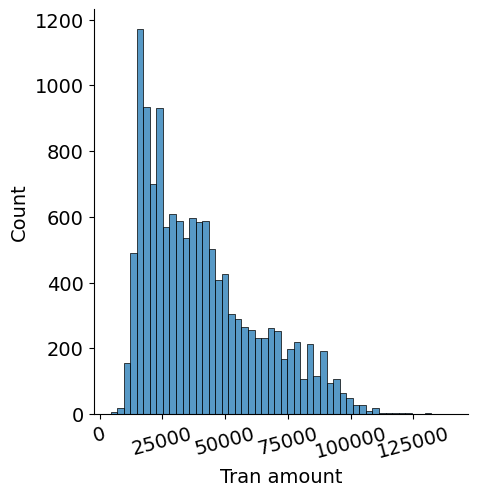

In [ ]:
plt.figure(figsize=(15, 4))
sns.displot(data['Tran amount'])
plt.tick_params(axis='x', labelrotation=15)

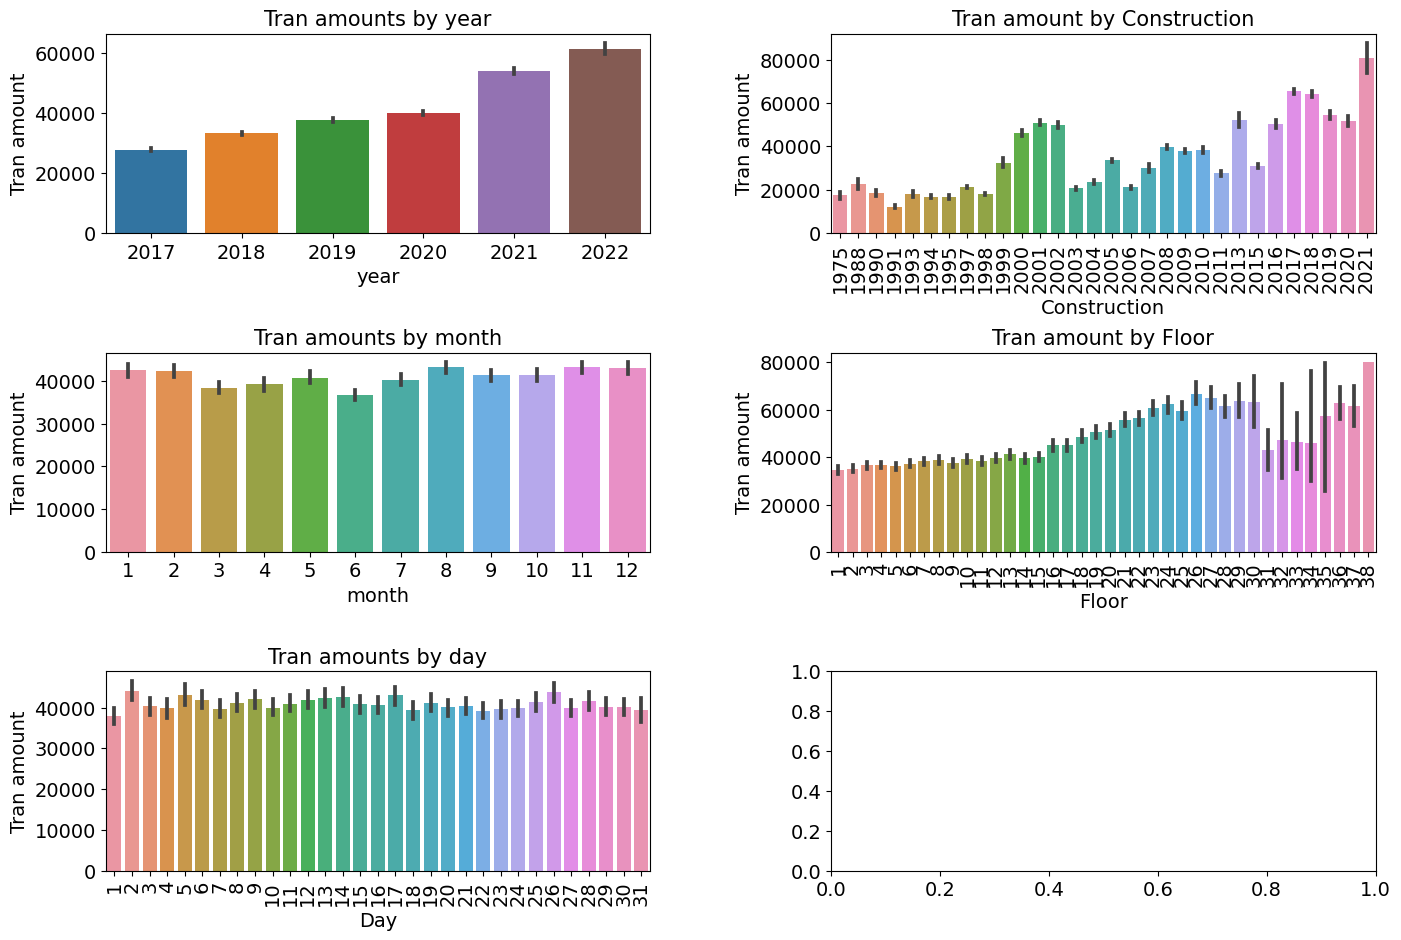

In [ ]:
mpl.rc('font', size=14)
mpl.rc('axes', titlesize=15)
figure, axes = plt.subplots(nrows=3, ncols=2)
plt.tight_layout()
figure.set_size_inches(15, 10)

sns.barplot(x='year', y='Tran amount', data=data, ax=axes[0,0])
sns.barplot(x='month', y='Tran amount', data=data, ax=axes[1,0])
sns.barplot(x='Day', y='Tran amount', data=data, ax=axes[2,0])
sns.barplot(x='Construction', y='Tran amount', data=data, ax=axes[0,1])
sns.barplot(x='Floor', y='Tran amount', data=data, ax=axes[1,1])


axes[0,0].set(title='Tran amounts by year')
axes[1,0].set(title='Tran amounts by month')
axes[2,0].set(title='Tran amounts by day')
axes[0,1].set(title='Tran amount by Construction')
axes[1,1].set(title='Tran amount by Floor')

axes[2, 0].tick_params(axis='x', labelrotation=90)
axes[0, 1].tick_params(axis='x', labelrotation=90)
axes[1, 1].tick_params(axis='x', labelrotation=90)

#연도, 월, 일, 건축년도, 층수에 따른 아파트 실거래가 데이터를 산출해보았다. (면적은 연속형 데이터이기 때문에 막대그래프에 적합치 않다 판단되어 논외로 두었다.)
#연도가 지날수록 아파트 실거래가는 증가함을 보인다. 2021년부터 급격한 성장세를 보였다.
#(사족이긴 하나, 서울에서 수도권으로 이주하는 사람들이 이유가 아닐까 싶다.)

#월, 일은 아파트 실거래가를 측정하기에 적합치 않다.
#건축년도는 1999~2002년, 2008~2010년, 2017~2021 구간에 높은 아파트 실거래가를 보였다.
#(특정 구간에 가격이 높음을 보이고 있으며, 실거래가와의 연관성이 다분해 보임을 증명하는 요인이 아닐까 싶다.)

#층수는 높아질수록 거래가의 증가를 보이나 고층일 때 급작스레 낮아졌다. 이는 고액의 아파트와 저액의 아파트의 개수 비율이 달라 벌어진 일이라 추측된다.
#(층수는 실거래가에 영향이 미심쩍긴 하나 어느 정도 있음을 보인다.)

In [ ]:
data.columns

Index(['Area', 'YearMonth', 'Day', 'Tran amount', 'Floor', 'Construction',
       'Motrgage loan', 'Fixed rate', 'Variable housing', 'trainpass', 'year',
       'month'],
      dtype='object')

[Text(0.5, 1.0, 'Area by year')]

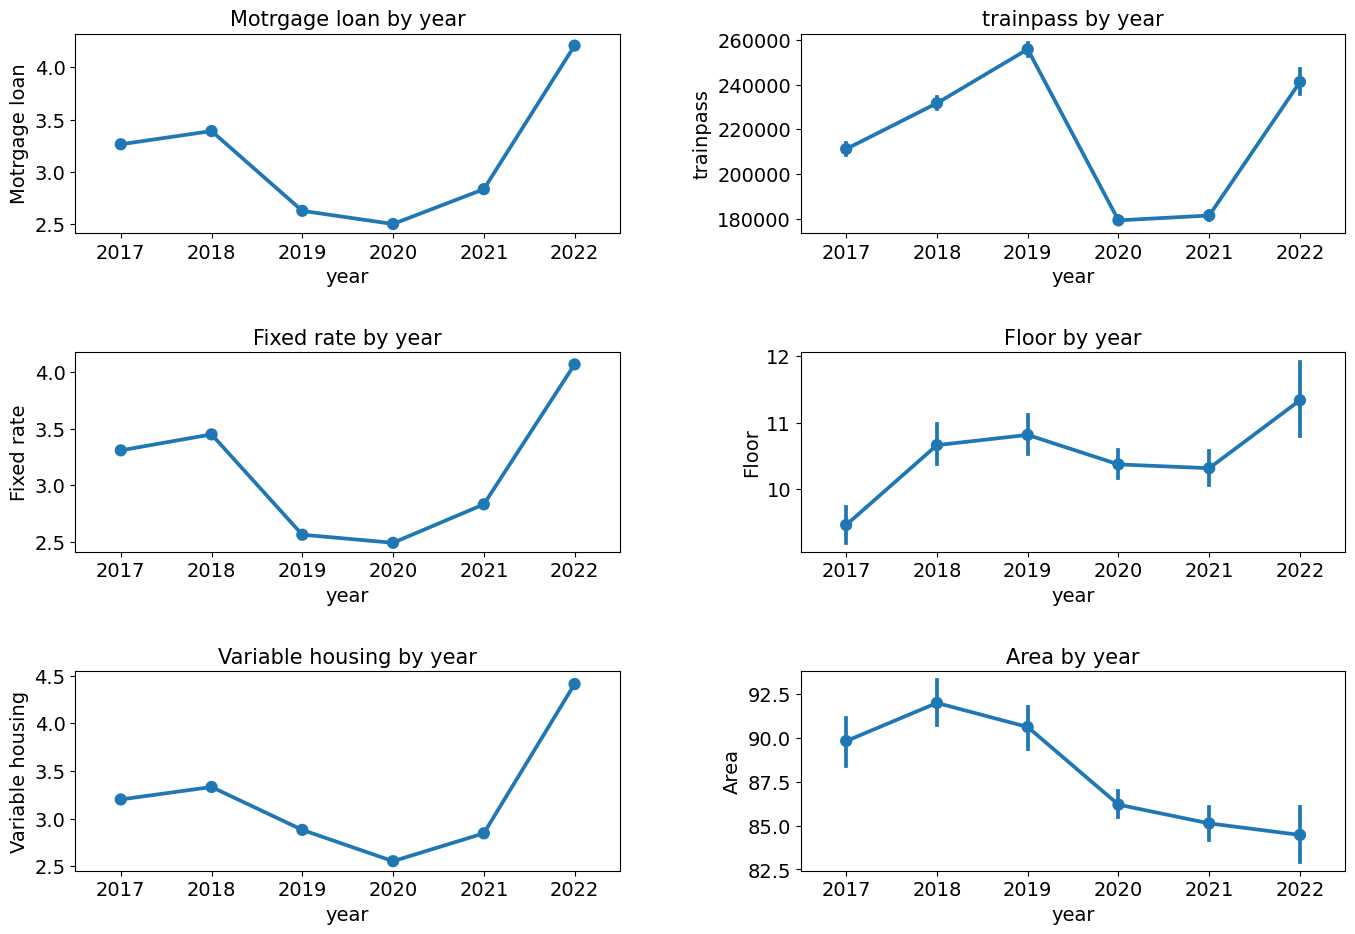

In [ ]:
mpl.rc('font', size=14)
mpl.rc('axes', titlesize=15)
figure, axes = plt.subplots(nrows=3, ncols=2)
plt.tight_layout()
figure.set_size_inches(15, 10)

sns.pointplot(x='year', y='Motrgage loan', data=data, ax=axes[0,0])
sns.pointplot(x='year', y='Fixed rate', data=data, ax=axes[1,0])
sns.pointplot(x='year', y='Variable housing', data=data, ax=axes[2,0])
sns.pointplot(x='year', y='trainpass', data=data, ax=axes[0,1])
sns.pointplot(x='year', y='Floor', data=data, ax=axes[1,1])
sns.pointplot(x='year', y='Area', data=data, ax=axes[2,1])

axes[0,0].set(title='Motrgage loan by year')
axes[1,0].set(title='Fixed rate by year')
axes[2,0].set(title='Variable housing by year')
axes[0,1].set(title='trainpass by year')
axes[1,1].set(title='Floor by year')
axes[2,1].set(title='Area by year')

###연도에 따른 주택담보대출금리(일반, 고정, 변동) 변화도와 지하철 유동인구, 층수, 아파트 면적의 변화율###

#세 종류의 금리 전부 다 2020년을 기점으로 급격한 성장세를 보였다.
#금리의 급격한 성장세를 보면 연도에 따른 아파트 실거래가에 영향이 클 것이라 예상되나,
#금리가 저하된 구간(2018~2020)이 있었음에도 아파트 실거래가는 지속적인 증가를 보였다.
#결국 금리의 급격한 증가는 아파트의 실거래가 변화에 어느 정도 영향을 주었을 지는 몰라도, 금리가 저하된 구간에 아파트 실거래가가
#구애받지 않은 점을 보아 직접적이지 않을 것이라 판단된다.


#지하철 유동인구는 2020년~2021년 최저의 수치를 보이다 2022년에 급격히 증가하였음을 보이는데, 최저 수치의 구간은 코로나 19라는 펜데믹의 영향이 클 것으로 보인다.(필자의 주관적 의견)
#지하철 유동인구는 금리의 변화량과 실거래가의 관계를 들어서 본다면, 아파트 실거래가에 큰 영향을 미치지 않을 것이라 판단되었으나, 상관계수에서 큰 연관성을 보였다.
#교통(사회)의 연관성은 절대로 무시 못할 부분이다.


#층수는 시간의 흐름에 따라 점차 높아지는 수치를 보였는데, 이는 다산동, 화도읍에 고층 아파트가 들어서고 있다는 점을 반영한다.


#반면, 면적은 시간에 지남에 따라 낮아짐을 보이고 있으나,
#pointplot는 평균을 반영하며 고액의 아파트와 저액의 아파트의 비율의 차이가 크다는 점을 고려하면, 실거래가에 대입하기에는 다소 어려움이 있다.
#그래도 연관성을 부인하기 어렵다.

<Axes: >

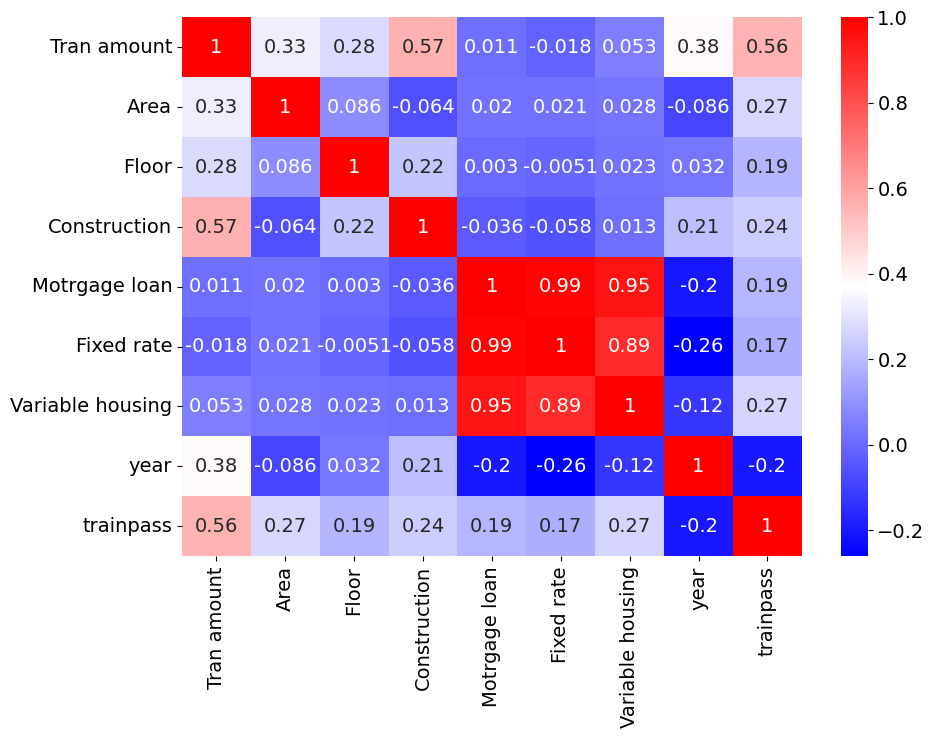

In [ ]:
plt.figure(figsize=(10, 7))
CorrMat = data[['Tran amount', 'Area', 'Floor', 'Construction',
       'Motrgage loan', 'Fixed rate', 'Variable housing', 'year', 'trainpass']].corr()
sns.heatmap(CorrMat, cmap='bwr', annot=True)

#데이터 시각화를 통해 실거래가와 다른 피처의 연관성을 예측해 보았으나, 예상과는 다른 변화율을 보이는 피처들이 몇몇 보였다.
#보다 한눈에, 직접적으로 연관성을 파악하기 위해 상관계수와 히트맵을 작성해 보았다.
#(PPT에 상관계수가 높은 피처대로 순위를 정해, 결과를 설명해도 좋을 것 같습니다.)

#상관계수를 통해 실거래가와 다른 피처와의 관계를 측정한 결과#
#건축년도, 지하철 유동인구, 연도, 층수, 면적이 실거래가와 연관이 높음을 보였다.

#3종류의 금리는 예상과 다르게 실거래가에 큰 연관을 보이지 않았다. 3종류를 상대적으로 비교해 보면 변동금리가 실거래가와 높은 연관성을 보이나,
#앞으로 전개할 모델의 점수에 좋은 영향을 줄 지는 확신이 어렵다.

In [ ]:
data.columns

Index(['Area', 'YearMonth', 'Day', 'Tran amount', 'Floor', 'Construction',
       'Motrgage loan', 'Fixed rate', 'Variable housing', 'trainpass', 'year',
       'month'],
      dtype='object')

In [ ]:
#상관계수를 기반으로 제작, 조합한 피처를 선형회귀, 트리, 랜덤포레스트, k-폴드, 그리드 서치 모델로 돌려 예측한 값들이다.
#점수는 train, test 순서로 적어넣었고, 수가 적을수록 정확도가 높은 트리다.

# 피처1: 'Area', 'Floor', 'Construction', 'trainpass', 'year'
# <평가지표 점수: train, test>
# 선형회귀: 11935.264, 19144.628
# 트리: 10543.089, 25526.186
# $$$랜덤포레스트: 2018.798, 8047.489
# $$$K폴드 교차검증: 2018.798, 8047.489
# 그리드서치: 3536.773, 9127.690
# *전체 다 그래프가 영....
##=> 랜덤포레스트, k-폴드 교차검증 예측값(test)이 8047.489로 가장 낮은 수치(정확도가 높다)를 보였다.

# 피처2: 'Area', 'Floor', 'Construction', 'trainpass'
# <평가지표 점수: train, test>
# 선형회귀:  16579.774, 11348.088
# 트리:  12295.972, 12506.949
# $$$랜덤포레스트: 2681.578, 11742.648
# K폴드 교차검증: 2633.322, 11770.222
# 그리드서치: 10081.326, 12136.705
##=> 선형회귀 예측값이 11348.088로 가장 낮은 수치를 보였다.

# 피처3: 'Area', 'Floor', 'Construction', 'trainpass', 'Variable housing'
# <평가지표 점수: train, test>
# 선형회귀: 16231.341, 12615.555
# 트리:12295.972, 12506.949
# 랜덤포레스트: 2213.186, 11828.679
# K폴드 교차검증: 2149.603, 11837.621
# $$$그리드서치: 3927.020, 11790.284
##=> 하이퍼파라미터-그리드 서치 예측값이 11790.284로 가장 낮은 수치를 보였다.

# 피처4: 'Area', 'Floor', 'Construction', 'trainpass', 'Variable housing', 'year'
# <평가지표 점수: train, test>
# 선형회귀: 11797.187, 19712.259
# 트리: 10543.089, 25526.186
# 랜덤포레스트: 1956.632, 10610.911
# $$$K폴드 교차검증: 1964.259, 8986.737
# 그리드서치: 1559.665, 9834.229
##=>k-폴드 교차검증 예측값 8986.737로 가장 낮은 수치를 보였다.


###결론: 피처1의 랜덤포레스트 모델, k-폴드 교차검증 모델이 가장 정확도 높은 모델임이 판정되었다.

#결론은 프로그램 맨 아래쪽에 기술해 두었습니다.


###모델 수치 설정###
#결정트리 깊이(depth): 3 (중요도를 간결히 보기 위해 조정)
#랜덤포레스트 샘플링 개수(n_estimator): 5
#k-폴드교차검증 폴드 수: 5
#하이퍼 파라메터 그리드 서치
# ('random_state', 'n_estimators', 'max_depth' ): 42, (5, 60, 6), (5, 40, 5)

In [ ]:
drop_features = ['YearMonth', 'Day', 'month','Motrgage loan', 'Fixed rate','Variable housing']

In [ ]:
data = data.drop(drop_features, axis=1)

In [ ]:
data

,Area,Tran amount,Floor,Construction,trainpass,year
0,75.7900,33500,6,2008,247187,2017
1,84.9500,33950,1,2008,247187,2017
2,84.9826,33800,8,2005,247187,2017
3,84.9826,34000,18,2005,247187,2017
4,59.8400,20900,7,1999,247187,2017
...,...,...,...,...,...,...
13540,148.0042,45000,23,2015,162363,2022
13541,84.9930,37000,16,2015,162363,2022
13542,59.7100,22500,15,1997,162363,2022
13543,59.8100,18900,9,2000,162363,2022


In [ ]:
X_train = data[0:9029]
X_test = data[9029:]
y_train = X_train[['Tran amount']]
y_test = X_test[['Tran amount']]

In [ ]:
del X_train['Tran amount']
del X_test['Tran amount']

In [ ]:
X_train

,Area,Floor,Construction,trainpass,year
0,75.7900,6,2008,247187,2017
1,84.9500,1,2008,247187,2017
2,84.9826,8,2005,247187,2017
3,84.9826,18,2005,247187,2017
4,59.8400,7,1999,247187,2017
...,...,...,...,...,...
9024,84.6000,5,1995,122630,2020
9025,84.6000,12,1995,122630,2020
9026,59.9350,10,1995,122630,2020
9027,84.8678,16,2008,122630,2020


In [ ]:
X_test

,Area,Floor,Construction,trainpass,year
9029,84.8678,15,2008,122630,2020
9030,84.8678,1,2008,122630,2020
9031,111.6100,15,2018,122630,2020
9032,84.9100,16,2018,122630,2020
9033,111.6100,4,2018,122630,2020
...,...,...,...,...,...
13540,148.0042,23,2015,162363,2022
13541,84.9930,16,2015,162363,2022
13542,59.7100,15,1997,162363,2022
13543,59.8100,9,2000,162363,2022


In [ ]:
y_train

,Tran amount
0,33500
1,33950
2,33800
3,34000
4,20900
...,...
9024,20000
9025,17350
9026,13500
9027,22100


In [ ]:
y_test

,Tran amount
9029,22300
9030,19700
9031,37400
9032,31900
9033,37800
...,...
13540,45000
13541,37000
13542,22500
13543,18900


In [ ]:
###위 함수까지 데이터 정리###

In [ ]:
def RMSE(y_true,y_pred):
  output = np.sqrt(np.mean((y_true-y_pred)**2))
  return output

In [ ]:
from sklearn.linear_model import LinearRegression
Lin_model = LinearRegression()

In [ ]:
Lin_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
Lin_model.coef_
#아래 변수들의 계수

array([[2.48538323e+02, 2.59747763e+02, 1.07655416e+03, 7.89405830e-02,
        8.99526592e+03]])

In [ ]:
X_train.columns

Index(['Area', 'Floor', 'Construction', 'trainpass', 'year'], dtype='object')

In [ ]:
Lin_model.intercept_
#선형회귀 결과의 상수항

array([-20320495.14148217])

In [ ]:
Lin_model.predict(X_train)

array([[24585.26874155],
       [25563.1409676 ],
       [24159.81517291],
       ...,
       [24841.67615306],
       [46592.12313125],
       [46592.12313125]])

In [ ]:
Lin_model.predict(X_test)

array([[46332.3753684 ],
       [42695.90668857],
       [63744.37852753],
       ...,
       [49364.68019151],
       [51060.7099307 ],
       [41083.26673323]])

In [ ]:
y_pred_train = Lin_model.predict(X_train)
y_pred_test = Lin_model.predict(X_test)

In [ ]:
RMSE(np.array(y_train), y_pred_train)

11935.26422206515

In [ ]:
RMSE(np.array(y_test), y_pred_test)

19144.628199366092

In [ ]:
y_train.shape

(9029, 1)

In [ ]:
y_pred_train.shape

(9029, 1)

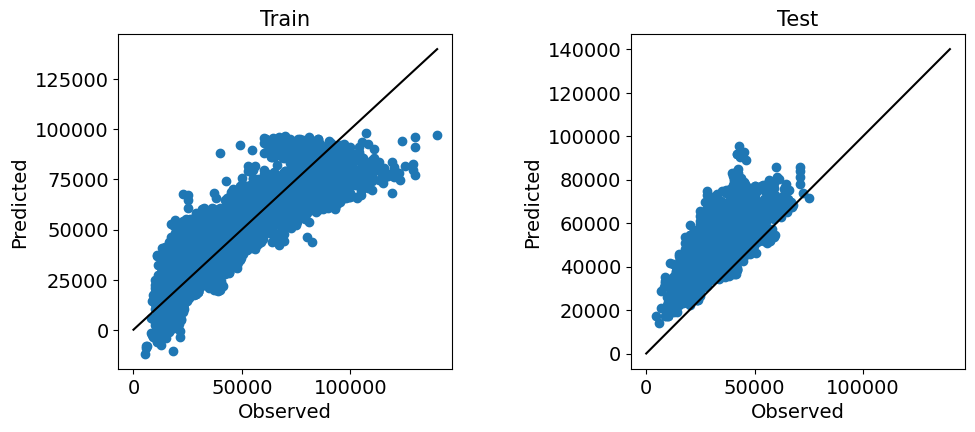

In [ ]:
fig, axs = plt.subplots(1,2)
plt.tight_layout(h_pad=3, w_pad=3)
fig.set_size_inches(10,4)

x = np.linspace(0,140000)
y=x
axs[0].plot(y_train, y_pred_train,'o', x,y,'k' )
axs[0].set_title('Train')

axs[0].set_xlabel('Observed')
axs[0].set_ylabel('Predicted')

axs[1].plot(y_test,y_pred_test,'o',x,y,'k')
axs[1].set_title('Test')

axs[1].set_xlabel('Observed')
axs[1].set_ylabel('Predicted')
plt.show()

In [ ]:
Lin_log_model =  LinearRegression()

In [ ]:
log_y_train = np.log(y_train+1)
log_y_test = np.log(y_test+1)
Lin_log_model.fit(X_train,log_y_train)

LinearRegression()

In [ ]:
Lin_log_model.coef_

array([[7.09843126e-03, 5.45429178e-03, 2.88589901e-02, 3.15565588e-06,
        1.68866092e-01]])

In [ ]:
X_train.columns

Index(['Area', 'Floor', 'Construction', 'trainpass', 'year'], dtype='object')

In [ ]:
Lin_log_model.intercept_

array([-389.74816871])

In [ ]:
temp_train = Lin_log_model.predict(X_train)
temp_test = Lin_log_model.predict(X_test)

In [ ]:
y_pred_logtrain = np.exp(temp_train)-1
y_pred_logtest = np.exp(temp_test)-1

In [ ]:
RMSE(np.array(y_train),y_pred_logtrain)

12905.606295663847

In [ ]:
RMSE(np.array(y_test),y_pred_logtest)

9035.394445183574

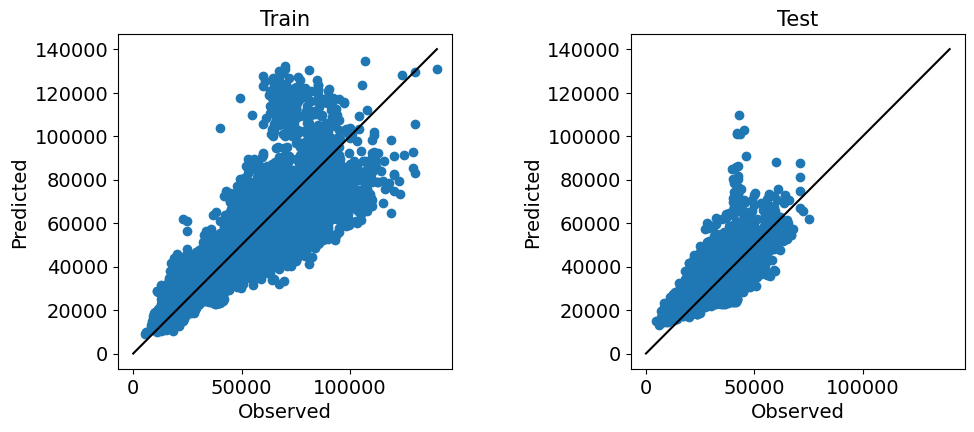

In [ ]:
fig, axs = plt.subplots(1,2)
plt.tight_layout(h_pad=3, w_pad=3)
fig.set_size_inches(10,4)

x = np.linspace(0,140000)
y=x
axs[0].plot(y_train, y_pred_logtrain,'o', x,y,'k' )
axs[0].set_title('Train')

axs[0].set_xlabel('Observed')
axs[0].set_ylabel('Predicted')

axs[1].plot(y_test,y_pred_logtest,'o',x,y,'k')
axs[1].set_title('Test')

axs[1].set_xlabel('Observed')
axs[1].set_ylabel('Predicted')
plt.show()

In [ ]:
###위 함수까지 선형회귀 분석###

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [ ]:
Tree_model = DecisionTreeRegressor(max_depth=3) #깊이는 얼마 정도가 적당할까?
Tree_model.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=3)

In [ ]:
Tree_model.predict(X_train)

array([40498.0131779 , 40498.0131779 , 40498.0131779 , ...,
       49518.47192225, 49518.47192225, 49518.47192225])

In [ ]:
Tree_model.predict(X_test)

array([49518.47192225, 49518.47192225, 27919.30952381, ...,
       49518.47192225, 49518.47192225, 49518.47192225])

In [ ]:
Tree_model.predict(X_train).shape
#결과가 1차원이다

(9029,)

In [ ]:
Tree_model.predict(X_test).shape

(4516,)

In [ ]:
Tree_model.predict(X_train).reshape(-1,1).shape
#이렇게 1차원을 막아야 함
#-1이 쓸 일이 많을 것이다

(9029, 1)

In [ ]:
Tree_model.predict(X_test).reshape(-1,1).shape

(4516, 1)

In [ ]:
Tree_pred_train = Tree_model.predict(X_train).reshape(-1,1)
Tree_pred_test = Tree_model.predict(X_test).reshape(-1,1)

In [ ]:
RMSE(np.array(y_train), Tree_pred_train)

10543.089835633256

In [ ]:
RMSE(np.array(y_test), Tree_pred_test)
#깊이는 3으로 절충했다.

25526.186813615397

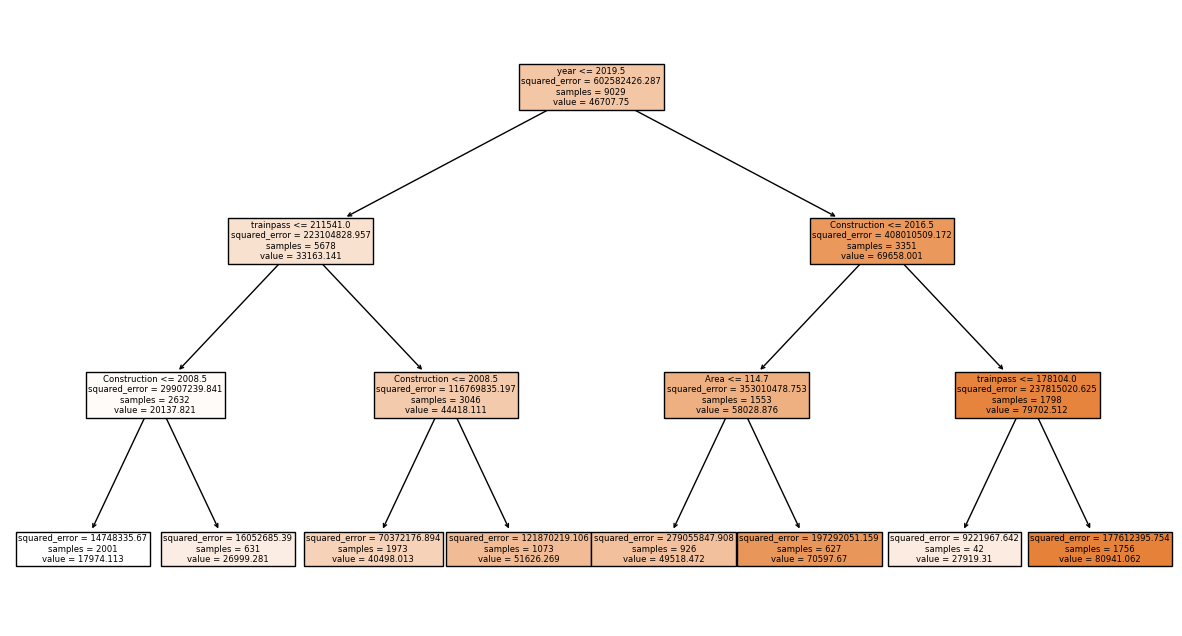

In [ ]:
plt.figure(figsize=(15,8))
plot_tree(Tree_model, feature_names=X_train.columns, filled = True);

In [ ]:
Tree_model.feature_importances_

array([0.03743844, 0.        , 0.11642145, 0.21358836, 0.63255175])

In [ ]:
X_train.columns
#중요도 순: year, trainpass, Construction, Area

Index(['Area', 'Floor', 'Construction', 'trainpass', 'year'], dtype='object')

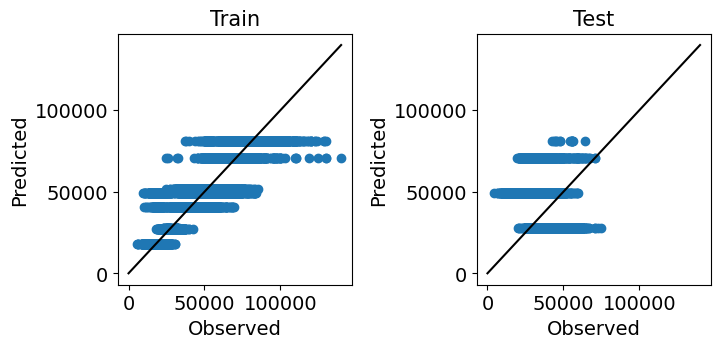

In [ ]:
fig, axs = plt.subplots(1,2)
plt.tight_layout(h_pad=3, w_pad=3)
fig.set_size_inches(7,3)

x = np.linspace(0,140000)
y=x
axs[0].plot(y_train, Tree_pred_train,'o', x,y,'k' )
axs[0].set_title('Train')

axs[0].set_xlabel('Observed')
axs[0].set_ylabel('Predicted')

axs[1].plot(y_test,Tree_pred_test,'o',x,y,'k')
axs[1].set_title('Test')

axs[1].set_xlabel('Observed')
axs[1].set_ylabel('Predicted')
plt.show()

In [ ]:
train_RMSE=[]
test_RMSE=[]
for i in range(40):
  Tree_model = DecisionTreeRegressor(max_depth=i+1)
  Tree_model.fit(X_train,y_train)
  Tree_pred_train = Tree_model.predict(X_train).reshape(-1,1)
  Tree_pred_test = Tree_model.predict(X_test).reshape(-1,1)
  train_RMSE.append(RMSE(np.array(y_train),Tree_pred_train))
  test_RMSE.append(RMSE(np.array(y_test),Tree_pred_test))

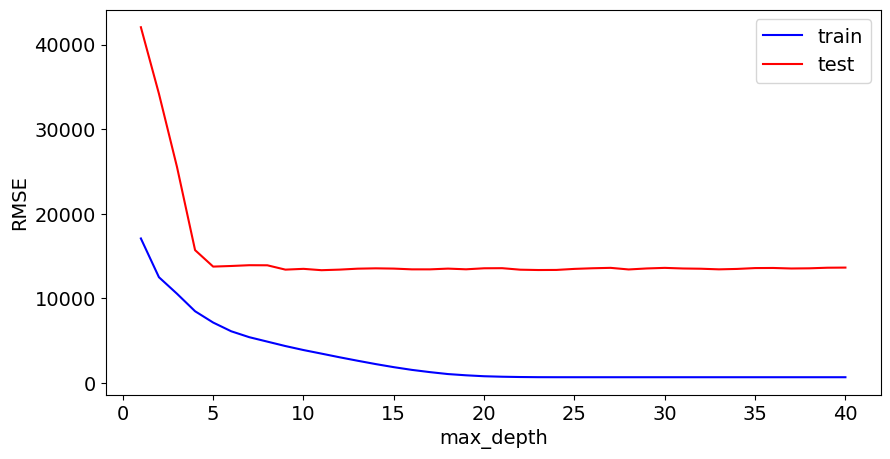

In [ ]:
plt.figure(figsize=(10,5))
max_depth_num = np.linspace(1,40,40)
plt.plot(max_depth_num,train_RMSE,'b',max_depth_num,test_RMSE,'r')
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.legend(['train', 'test'])
plt.show()

#피처: 'Area', 'Floor', 'Construction', 'trainpass', 'year'
#train은 깊이가 깊어질수록 정확도가 높아지는데, test는 13000~14000 즈음~에서 더 이상 정확도가 좋아지지 않는다.
#깊이는 더 이상 test가 낮아지지 않는 5가 적당하다. (max_depth)

In [ ]:
###여기까지가 결정트리###

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
RF_model = RandomForestRegressor(n_estimators=5)
RF_model.fit(X_train, np.array(y_train).reshape(-1))
#n_extimators : 샘플링 개수 설정 코드

RandomForestRegressor(n_estimators=5)

In [ ]:
RF_pred_train=RF_model.predict(X_train)
RF_pred_test=RF_model.predict(X_test)

In [ ]:
RMSE(np.array(y_train), RF_pred_train.reshape(-1,1))

1991.776518400192

In [ ]:
RMSE(np.array(y_test), RF_pred_test.reshape(-1,1))
#결정트리보다 RMSE가 낮다. 보다 더 정확도가 높다.

9830.094459383807

In [ ]:
RF_model.feature_importances_
#중요도 순서: year, trainpass, Floor, Construction, Area

array([0.09142953, 0.01152461, 0.11396424, 0.34439264, 0.43868898])

In [ ]:
X_train.columns

Index(['Area', 'Floor', 'Construction', 'trainpass', 'year'], dtype='object')

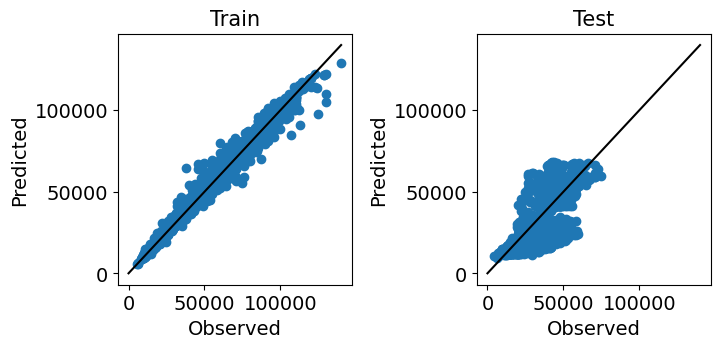

In [ ]:
fig, axs = plt.subplots(1,2)
plt.tight_layout(h_pad=3, w_pad=3)
fig.set_size_inches(7,3)

x = np.linspace(0,140000)
x1 = np.linspace(0,80000)
y=x
y1=x1
axs[0].plot(y_train, RF_pred_train,'o', x,y,'k' )
axs[0].set_title('Train')

axs[0].set_xlabel('Observed')
axs[0].set_ylabel('Predicted')

axs[1].plot(y_test,RF_pred_test,'o',x,y,'k')
axs[1].set_title('Test')

axs[1].set_xlabel('Observed')
axs[1].set_ylabel('Predicted')
plt.show()

In [ ]:
###여기까지 랜덤 포레스트###

In [ ]:
from sklearn.model_selection import KFold

In [ ]:
folds = KFold(random_state = 42, n_splits = 5, shuffle = True)
#n_splits = 폴드 수

In [ ]:
X = np.array(X_train)
y = np.array(y_train)

In [ ]:
RMSE_valid = []
for train_index, valid_index in folds.split(X):
  X_train_2, X_valid = X[train_index], X[valid_index]
  y_train_2, y_valid = y[train_index], y[valid_index]

  RF_valid_model = RandomForestRegressor(random_state = 42, n_estimators = 10)
  RF_valid_model.fit(X_train_2, y_train_2.reshape(-1))

  RF_valid_pred = RF_valid_model.predict(X_valid).reshape(-1, 1)
  RMSE_valid.append(RMSE(y_valid, RF_valid_pred))

  #randon_state로 보정을 시키면 값이 동일하게 나온다.

In [ ]:
RMSE_valid
#k개의 교차검증 결과

[4230.27259250578,
 4209.69266767511,
 4290.115539833923,
 4076.082495983228,
 4026.8624516814493]

In [ ]:
np.mean(RMSE_valid)
#교차검증 결과 평균

4166.605149535898

In [ ]:
###여기까지 K-폴드 교차검증###

In [ ]:
#5번의 학습을 통해 앙상블 모델 만들기
X_test_2 = np.array(X_test)

In [ ]:
RMSE_valid = []
CV_pred_train = np.zeros(shape=(len(X),5))
CV_pred_test = np.zeros(shape=(len(X_test_2),5))
num = 0
for train_index, valid_index in folds.split(X):
  X_train_2, X_valid = X[train_index], X[valid_index]
  y_train_2, y_valid = y[train_index], y[valid_index]

  RF_valid_model = RandomForestRegressor(random_state = 42, n_estimators = 10)
  RF_valid_model.fit(X_train_2, y_train_2.reshape(-1))

  RF_valid_pred = RF_valid_model.predict(X_valid).reshape(-1, 1)
  RMSE_valid.append(RMSE(y_valid, RF_valid_pred))

  CV_pred_train[:,num] = RF_valid_model.predict(X)
  CV_pred_test[:,num] = RF_valid_model.predict(X_test_2)
  num = num + 1

In [ ]:
CV_pred_train

array([[34795.        , 34270.        , 34400.        , 34375.        ,
        34470.        ],
       [34227.        , 34003.33333333, 33907.5       , 34615.83333333,
        34130.        ],
       [33810.        , 33670.        , 33695.        , 33685.        ,
        34425.        ],
       ...,
       [13460.        , 13540.        , 13485.        , 14385.        ,
        13200.        ],
       [23440.        , 23134.64285714, 22350.        , 23429.64285714,
        22450.85714286],
       [23440.        , 23134.64285714, 22350.        , 23429.64285714,
        22450.85714286]])

In [ ]:
CV_pred_test

array([[23440.        , 23084.64285714, 22390.        , 22962.14285714,
        22490.85714286],
       [21793.5       , 21562.5       , 21930.        , 21945.        ,
        21946.66666667],
       [33410.        , 33250.        , 34845.        , 32645.        ,
        32835.        ],
       ...,
       [17370.        , 14330.        , 14090.        , 19520.        ,
        16970.        ],
       [31040.        , 15030.        , 20895.        , 23280.        ,
        23290.        ],
       [19205.        , 10128.66666667, 10860.        , 11950.        ,
        13858.66666667]])

In [ ]:
y_train_result = np.mean(CV_pred_train, axis = 1).reshape(-1, 1)

In [ ]:
y_test_result = np.mean(CV_pred_test, axis = 1).reshape(-1, 1)

In [ ]:
RMSE(np.array(y_train), y_train_result)

2018.798207667764

In [ ]:
RMSE(np.array(y_test), y_test_result)

8047.489060215612

In [ ]:
###5번의 양상블 모델###

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

In [ ]:
RF_model = RandomForestRegressor()

In [ ]:
RMSE_scorer = metrics.make_scorer(RMSE, greater_is_better = False)

In [ ]:
RF_params = {'random_state' : [42], 'n_estimators' : list(range(5, 60, 5)), 'max_depth' : list(range(5, 40, 5))}

In [ ]:
GS_RF_model = GridSearchCV(estimator = RF_model,
                           param_grid = RF_params,
                           scoring = RMSE_scorer,
                           cv = 4)

In [ ]:
GS_RF_model.fit(X_train, np.array(y_train).reshape(-1))

GridSearchCV(cv=4, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [5, 10, 15, 20, 25, 30, 35],
                         'n_estimators': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50,
                                          55],
                         'random_state': [42]},
             scoring=make_scorer(RMSE, greater_is_better=False))

In [ ]:
GS_RF_model.best_params_

{'max_depth': 10, 'n_estimators': 55, 'random_state': 42}

In [ ]:
GS_RF_model.best_estimator_.predict(X_train)

array([35844.68768858, 34785.84160722, 34473.0390811 , ...,
       13901.32776285, 22437.76585199, 22437.76585199])

In [ ]:
GS_pred_train = GS_RF_model.best_estimator_.predict(X_train).reshape(-1, 1)
GS_pred_test = GS_RF_model.best_estimator_.predict(X_test).reshape(-1, 1)

In [ ]:
RMSE(np.array(y_train), GS_pred_train)

3536.773075711372

In [ ]:
RMSE(np.array(y_test), GS_pred_test)

9127.690069755952

In [ ]:
###여기까지 하이퍼파라메터 - 그리드서치###

In [ ]:
#우리가 아파트의 실거래가을 예측하는 과정에서 금리라는 경제적 요인이 큰 영향을 미칠 것이라 예측하였으나,
#예상과는 다르게 금리는 남양주시의 화도읍, 다산동의 아파트 실거래가에 큰 영향을 주지 못하였다.
#'Area', 'Floor', 'Construction', 'trainpass', 'year', 아파트의 면적, 층수, 건축년도, 지하철 유동인구수, 연도가 아파트 실거래가에 가장 큰 영향을 미쳤다.
#이는 다산동, 화도읍의 아파트 실거래가는 주거, 사회의 영향을 가장 많이 받음을 알 수가 있다.
#주거(면적, 층수, 건축년도)
#사회(지하철 유동인구수, 연도)
#사회적 요인 중 연도가 모델에 주는 영향은 컸는데, 이는 남양주시가 수도권에 위치해 있으며, 서울에서 수도권으로 사람들이 이주하면서 생긴 현상으로 이야기할 수 있을까는 생각도 든다.
#연도year 피처는 사회 범주에 들어간다 생각되지만, 경제활동을 하는 것은 사람에게 비롯되니, 경제적 요인도 포함되리라 생각한다.(필자의 생각)
#주거, 사회, 경제의 관계는 유기적이기 때문에 어느 하나를 별개로 두고 생각한다는 건 불가능하다. 다만 비중의 차이라 생각된다.

#요약
#1. 예상과는 다르게 금리는 실거래가에 큰 영향을 주지 못했다.
#2. 주거 1순위, 사회 2순위로 남양주시 화도읍, 다산동의 실거래가에 큰 영향을 주었다.